شكل الصور: (42718, 64, 64, 1)
أقصى قيمة: 1.0
أقل قيمة: 0.0
نوع البيانات: float32


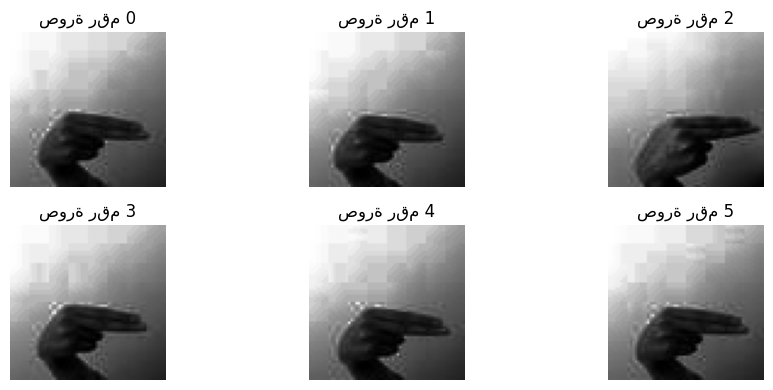

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# تحميل الصور من Google Drive
images = np.load('/content/drive/MyDrive/images_original.npy')

# عرض معلومات أساسية
print("شكل الصور:", images.shape)
print("أقصى قيمة:", images.max())
print("أقل قيمة:", images.min())
print("نوع البيانات:", images.dtype)

# عرض أول 6 صور من العينة
plt.figure(figsize=(10, 4))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(f"صورة رقم {i}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# --- 1. استيراد المكتبات ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Lambda
import tensorflow as tf
from tensorflow.keras import layers

# --- 2. تحميل البيانات ---
X = np.load('/content/drive/MyDrive/images_original.npy')  # (42718, 64, 64, 1)
y = np.load('/content/drive/MyDrive/encoded_labels_original.npy')

# --- 3. تطبيع الصور ---
X = X.astype('float32')  # القيم من 0 إلى 1 بالفعل

# --- 4. تقسيم البيانات ---
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# --- 5. بناء النموذج باستخدام VGG16 مع تحويل داخلي من 1 قناة إلى 3 ---
input_shape = (64, 64, 1)
num_classes = len(np.unique(y))

inputs = Input(shape=input_shape)

# تحويل الصور الرمادية إلى 3 قنوات باستخدام Conv2D بدلاً من np.repeat
x = Conv2D(3, (3, 3), padding='same', activation='relu')(inputs)

# تحميل VGG16 بدون الطبقات العليا
base_model = VGG16(include_top=False, weights='imagenet', input_shape=(64, 64, 3))
base_model.trainable = False  # تجميد الطبقات لمنع استهلاك الذاكرة

x = base_model(x)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

# --- 6. تجميع النموذج ---
model.compile(optimizer=Adam(1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 3)      │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         4,128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,784,510 (56.40 MB)

 Trainable params: 69,822 (272.74 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/40
534/534 ━━━━━━━━━━━━━━━━━━━━ 37s 68ms/step - accuracy: 0.8830 - loss: 0.3927 - val_accuracy: 0.9532 - val_loss: 0.2265
Epoch 2/40
534/534 ━━━━━━━━━━━━━━━━━━━━ 42s 70ms/step - accuracy: 0.8837 - loss: 0.3898 - val_accuracy: 0.9547 - val_loss: 0.2227
Epoch 3/40
534/534 ━━━━━━━━━━━━━━━━━━━━ 38s 71ms/step - accuracy: 0.8905 - loss: 0.3764 - val_accuracy: 0.9560 - val_loss: 0.2154
Epoch 4/40
534/534 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - accuracy: 0.8923 - loss: 0.3712 - val_accuracy: 0.9569 - val_loss: 0.2096
Epoch 5/40
534/534 ━━━━━━━━━━━━━━━━━━━━ 41s 71ms/step - accuracy: 0.8921 - loss: 0.3660 - val_accuracy: 0.9572 - val_loss: 0.2043
Epoch 6/40
534/534 ━━━━━━━━━━━━━━━━━━━━ 41s 72ms/step - accuracy: 0.9031 - loss: 0.3523 - val_accuracy: 0.9587 - val_loss: 0.1990
Epoch 7/40
534/534 ━━━━━━━━━━━━━━━━━━━━ 42s 73ms/step - accuracy: 0.9002 - loss: 0.3499 - val_accuracy: 0.9595 - val_loss: 0.1951
Epoch 8/40
534/534 ━━━━━━━━━━━━━━━━━━━━ 41s 73ms/step - accuracy: 0.9035 - loss: 0.3368 - 

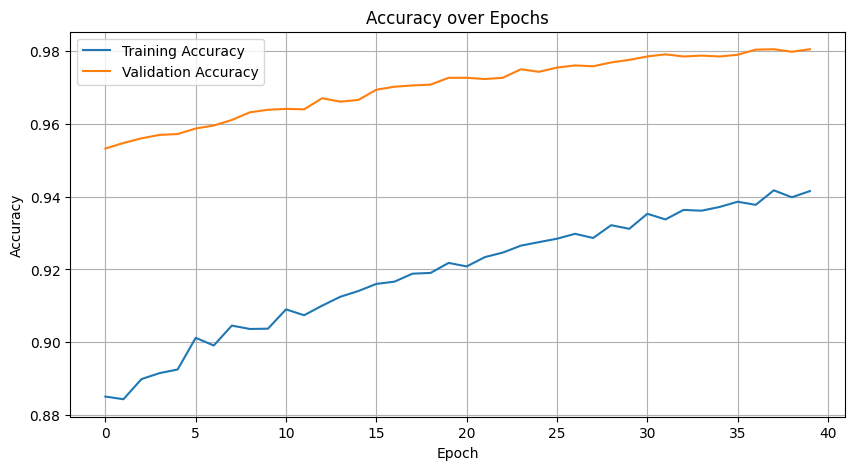


🔎 Accuracy لكل Epoch:
Epoch 1: Train Acc = 0.8851 | Val Acc = 0.9532
Epoch 2: Train Acc = 0.8844 | Val Acc = 0.9547
Epoch 3: Train Acc = 0.8899 | Val Acc = 0.9560
Epoch 4: Train Acc = 0.8915 | Val Acc = 0.9569
Epoch 5: Train Acc = 0.8925 | Val Acc = 0.9572
Epoch 6: Train Acc = 0.9012 | Val Acc = 0.9587
Epoch 7: Train Acc = 0.8991 | Val Acc = 0.9595
Epoch 8: Train Acc = 0.9046 | Val Acc = 0.9610
Epoch 9: Train Acc = 0.9036 | Val Acc = 0.9631
Epoch 10: Train Acc = 0.9037 | Val Acc = 0.9638
Epoch 11: Train Acc = 0.9090 | Val Acc = 0.9641
Epoch 12: Train Acc = 0.9074 | Val Acc = 0.9640
Epoch 13: Train Acc = 0.9100 | Val Acc = 0.9670
Epoch 14: Train Acc = 0.9125 | Val Acc = 0.9661
Epoch 15: Train Acc = 0.9141 | Val Acc = 0.9665
Epoch 16: Train Acc = 0.9160 | Val Acc = 0.9693
Epoch 17: Train Acc = 0.9166 | Val Acc = 0.9702
Epoch 18: Train Acc = 0.9188 | Val Acc = 0.9705
Epoch 19: Train Acc = 0.9190 | Val Acc = 0.9707
Epoch 20: Train Acc = 0.9218 | Val Acc = 0.9726
Epoch 21: Train Acc = 0.92

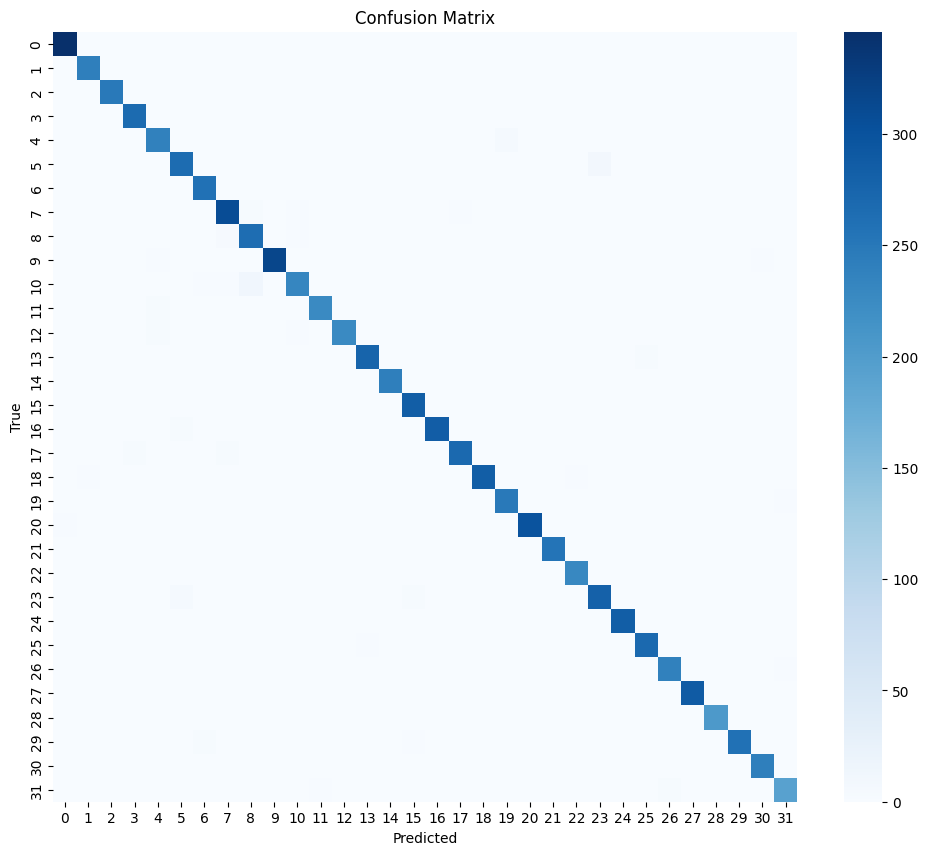


📌 Matthews Correlation Coefficient (MCC): 0.9798
📈 ROC AUC Score (macro, OvR): 0.9998


In [ ]:
# --- 7. تدريب النموذج ---
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=40, batch_size=64)

# --- 8. رسم منحنى الدقة ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# --- 9. عرض الدقة لكل Epoch ---
print("\n🔎 Accuracy لكل Epoch:")
for i in range(len(history.history['accuracy'])):
    print(f"Epoch {i+1}: Train Acc = {history.history['accuracy'][i]:.4f} | Val Acc = {history.history['val_accuracy'][i]:.4f}")

# --- 10. التقييم ---
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"\n✅ Total Validation Accuracy: {val_acc:.4f}")
print(f"❌ Total Validation Loss: {val_loss:.4f}")

# --- 11. التنبؤ ---
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# --- 12. مصفوفة الالتباس ---
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# --- 13. تقييم إضافي (MCC و ROC AUC) ---
from sklearn.metrics import matthews_corrcoef, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

mcc = matthews_corrcoef(y_val, y_pred)
print(f"\n📌 Matthews Correlation Coefficient (MCC): {mcc:.4f}")

y_val_bin = label_binarize(y_val, classes=np.arange(num_classes))
roc_auc = roc_auc_score(y_val_bin, y_pred_probs, average='macro', multi_class='ovr')
print(f"📈 ROC AUC Score (macro, OvR): {roc_auc:.4f}")


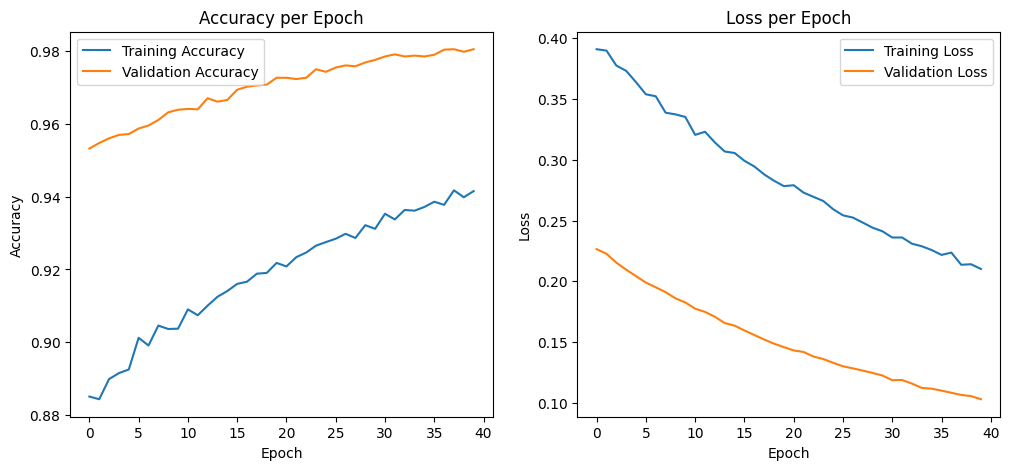

In [ ]:
# رسم Accuracy و Loss لكل epoch
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()
